# Modify a Reaction Network

In the previous notebook we used a ready-made carbon network that `potions`
ships with. Here we look at what happens when you want to **change** the
chemistry, or build it **from scratch** - the way you would for a specific
site. In particular we will:

- **Build the same simple carbon network by hand**, so you can see exactly what
  the helper function from notebook 6 was doing under the hood.
- **Add a new chemical species**: bicarbonate, `HCO3-`, the main dissolved
  *inorganic* carbon (DIC) in natural waters.
- **Change the stoichiometry of the soil-carbon reaction** so that the
  decomposition of soil organic carbon releases *both* organic carbon (DOC)
  and inorganic carbon (`HCO3-`):

$$\text{SOC(s)} \longrightarrow \text{DOC} + \text{HCO3-}$$

The result is a two-product respiration reaction, which lets us track the
organic and inorganic carbon leaving the catchment separately.

The steps are:

1. Load the input data
2. Set up the hydrologic model (as before - not the focus)
3. Open the chemical database and look inside the simple carbon network
4. Build the simple carbon network from scratch (by hand)
5. Modify it: add `HCO3-` and change the SOC reaction stoichiometry
6. Define the per-zone reactive-transport parameters
7. Assemble and run the modified model
8. View and plot the results

This is a Jupytext-style percent script: code cells are delimited by `# %%`
and text cells by `# %% [markdown]`.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from pandas import DataFrame, Series

import potions as pt

data_dir: str = "../data"
forcing_path: str = os.path.join(data_dir, "model_inputs", "forcing.csv")
measured_path: str = os.path.join(data_dir, "model_inputs", "measured_data.csv")

## 1. Load the input data

The same two files as before: the daily weather drivers, and the observations
(streamflow `q_mmd` and river DOC `doc_mol_l`). Only the streamflow and the DOC
column are used below.

In [2]:
forcing_df: DataFrame = pd.read_csv(forcing_path, index_col=0, parse_dates=True)
measured_df: DataFrame = pd.read_csv(measured_path, index_col=0, parse_dates=True)

meas_streamflow: Series = measured_df["q_mmd"]
meas_river_conc: DataFrame = measured_df["doc_mol_l"].to_frame("DOC")

print(
    f"Forcing spans {forcing_df.index[0].date()} to {forcing_df.index[-1].date()} ({len(forcing_df)} days)"
)
print(
    f"Meas. data  spans {measured_df.index[0].date()} to {measured_df.index[-1].date()} ({len(measured_df)} days)"
)

Forcing spans 2008-10-01 to 2015-09-30 (2554 days)
Meas. data  spans 2009-10-01 to 2015-09-30 (2191 days)


## 2. Set up the hydrologic model

Identical to the previous notebooks: a simple four-zone `HbvModel`. The water
movement is not changed here - we are only altering the chemistry that travels
with it.

In [3]:
forcing: pt.ForcingData = pt.ForcingData(
    precip=forcing_df["ppt"],
    temp=forcing_df["temp"],
    pet=forcing_df["pet"],
)

# Same custom hydrologic zone tuning as notebook 2 (hydrology is not the focus).
custom_zones: dict[str, pt.HydrologicZone] = {
    "snow": pt.SnowZone(tt=0.5, fmax=2.0),
    "surface": pt.SurfaceZone(fc=250.0, thr=25.0),
    "shallow": pt.GroundZone(k=2.0e-2, perc=0.5),
}

hydro_model: pt.HbvModel = pt.HbvModel(zones=custom_zones)
print("Hydrologic model zones:", ", ".join(hydro_model.get_zone_names()))

Hydrologic model zones: snow, surface, shallow, deep


## 3. Open the chemical database and look inside the simple carbon network

Every chemical species, solid, and reaction in `potions` is stored in a
**chemical database**. Here we load the built-in one and *inspect* the pieces
that make up the simple carbon network, so we understand what we will rebuild
by hand next.

A reaction has a **stoichiometry** (which species are consumed/produced, by how
much) and **kinetics** (how fast it runs). Let's read those out of the
database for the solid `SOC(s)`.

In [4]:
# Load the built-in chemical database (all the built-in species and reactions).
db: pt.ChemicalDatabase = pt.ChemicalDatabase.load_default()

# The dissolved DOC species and the SOC(s) solid, exactly as stored in the DB.
doc_species: pt.PrimaryAqueousSpecies = db.get_primary_aqueous_species(["DOC"])[0]
soc_species: pt.MineralSpecies = db.get_mineral_species(["SOC(s)"])[0]

print("DOC - molar mass:", doc_species.molar_mass, "g/mol, charge:", doc_species.charge)
print("SOC(s) - molar mass:", soc_species.molar_mass, "g/mol")
print()
print("Original SOC(s) reaction stoichiometry (from the database):")
print("   ", soc_species.stoichiometry)
print()
print("   -> One mole of SOC(s) decomposes into DOC and CO2(aq). (CO2(aq) is a")
print("      *secondary* species that would be speciated into HCO3-/H+/CO3-- in")
print("      the full carbon network.) We will instead release HCO3- directly.")

DOC - molar mass: 300.0 g/mol, charge: 0.0
SOC(s) - molar mass: 180.0 g/mol

Original SOC(s) reaction stoichiometry (from the database):
    {'CO2(aq)': 0.6, 'DOC': 0.55, 'SOC(s)': -1.0}

   -> One mole of SOC(s) decomposes into DOC and CO2(aq). (CO2(aq) is a
      *secondary* species that would be speciated into HCO3-/H+/CO3-- in
      the full carbon network.) We will instead release HCO3- directly.


## 4. Build the simple carbon network from scratch (by hand)

This is exactly what the `get_simple_carbon_network()` helper did in notebook 6,
written out step by step. A `ReactionNetwork` is built from four lists:

- `primary_aqueous` - the dissolved species that are tracked independently
  (here `DOC`),
- `mineral` - the solids that react (here `SOC(s)`),
- `mineral_kinetics` - the reaction rates for those solids,
- `secondary` and `exchange_species` - species that are speciated at
  equilibrium or sorbed (none in the simple network).

The kinetics are mined from the database by mineral name and a reaction label.
`SOC(s)` in the database has a Monod-limited (self-limiting) respiration
reaction under the label `"test"`.

In [15]:
# 1. The dissolved species.
primary: list[pt.PrimaryAqueousSpecies] = db.get_primary_aqueous_species(["DOC"])

# 2. The solid that reacts.
minerals: list[pt.MineralSpecies] = db.get_mineral_species(["SOC(s)"])

# 3. The reaction kinetics, looked up by (mineral name, label).
mineral_kinetics: pt.MineralKineticData = db.get_mineral_reactions(
    ["SOC(s)"], labels=["test"]
)

# 4. No secondary (speciated) or exchange (sorption) species in the simple network.
secondary: list[pt.SecondarySpecies] = []
exchange: list[pt.ExchangeReaction] = []

simple_network: pt.ReactionNetwork = pt.ReactionNetwork(
    primary_aqueous=primary,
    mineral=minerals,
    mineral_kinetics=mineral_kinetics,
    secondary=secondary,
    exchange_species=exchange,
)

print("Simple carbon network built by hand")
print("   Aqueous species:", simple_network.species_names)
print("   Solids:         ", list(simple_network.mineral_names))
print("   SOC(s) stoichiometry (unchanged):", soc_species.stoichiometry)

Simple carbon network built by hand
   Aqueous species: ['DOC', 'SOC(s)']
   Solids:          ['SOC(s)']
   SOC(s) stoichiometry (unchanged): {'CO2(aq)': 0.6, 'DOC': 0.55, 'SOC(s)': -1.0}


## 5. Modify it: add `HCO3-` and change the SOC reaction

Two changes make this a network we designed for our own purpose rather than the
built-in one.

**(a) Add a new aqueous species.** Bicarbonate `HCO3-` is a *primary* species
(tracked independently). We define it with a molar mass (61 g/mol) and charge
($-1$); the `dh_size_param` is a size parameter used in the transport
(Debye-Huckel) treatment - 4.0 is a reasonable default for a simple ion.

**(b) Change the reaction stoichiometry.** We keep the same `SOC(s)` solid and
its respiration *kinetics* (the rate behavior), but replace its stoichiometry so
that decomposing carbon releases **both DOC and HCO3-** instead of DOC and
CO2(aq). The coefficients are the fraction of the carbon that goes to each
product - here we send half to DOC and half to HCO3-. The solid itself is
consumed, so its coefficient is $-1$.

In [6]:
# (a) The new primary species: bicarbonate, the main dissolved inorganic carbon.
hco3_species: pt.PrimaryAqueousSpecies = pt.PrimaryAqueousSpecies(
    name="HCO3-",
    molar_mass=61.0,  # g/mol
    charge=-1.0,  # unit negative ion
    dh_size_param=4.0,  # transport size parameter
)

# (b) The same SOC(s) solid, but with a new two-product reaction stoichiometry.
#     0.5 -> DOC (organic carbon), 0.5 -> HCO3- (inorganic carbon), -1 -> SOC(s)
modified_soc: pt.MineralSpecies = pt.MineralSpecies(
    name="SOC(s)",
    molar_mass=soc_species.molar_mass,
    stoichiometry={"DOC": 0.5, "HCO3-": 0.5, "SOC(s)": -1.0},
    eq_consts=soc_species.eq_consts,  # keep the solid's existing equilibrium constants
    molar_volume=soc_species.molar_volume,
)

# Assemble the modified network: the same SOC kinetics, but with HCO3- now in the
# aqueous phase and the new two-product stoichiometry.
modified_network: pt.ReactionNetwork = pt.ReactionNetwork(
    primary_aqueous=[*primary, hco3_species],
    mineral=[modified_soc],
    mineral_kinetics=mineral_kinetics,  # unchanged reaction rates
    secondary=secondary,
    exchange_species=exchange,
)

print("Modified network")
print("   Aqueous species:   ", modified_network.species_names)
print("   Solids:            ", list(modified_network.mineral_names))
print("   Modified SOC(s) stoichiometry:", modified_soc.stoichiometry)
print("   New dissolved species 'HCO3-' is tracked independently.")

Modified network
   Aqueous species:    ['DOC', 'HCO3-', 'SOC(s)']
   Solids:             ['SOC(s)']
   Modified SOC(s) stoichiometry: {'HCO3-': 0.5, 'DOC': 0.5, 'SOC(s)': -1.0}
   New dissolved species 'HCO3-' is tracked independently.


## 6. Define the per-zone reactive-transport parameters

Identical in approach to notebook 6: one `RtZone` per hydrologic zone, each with
the shared `ZoneDimensions` and per-layer mineral parameters. The only
difference is that the network now carries an extra species, so the model tracks
one more quantity per zone - but we build the zones the same way.

In [7]:
zone_dimensions: pt.ZoneDimensions = pt.ZoneDimensions(
    porosity=0.5,
    depth=2_500.0,
    passive_water_storage=0.0,
)


def mineral_params_from_ssa(ssa: float, q10: float = 1.5) -> pt.MineralParameters:
    """Build the mineral parameters for a layer from a single surface-area value."""
    auxiliary: pt.MineralAuxParams = pt.MineralAuxParams(
        ssa=ssa,
        sw_threshold=0.5,
        sw_exp=1.0,
        q_10=q10,
    )
    return pt.MineralParameters.from_mineral_parameters([auxiliary])


rt_zones: dict[str, pt.RtZone] = {
    "snow": pt.RtZone(
        modified_network,
        pt.RtParameters(dimensions=zone_dimensions, mineral_params=None),
        do_reactions=False,
        do_speciation=False,
        name="snow",
    ),
    "surface": pt.RtZone(
        modified_network,
        pt.RtParameters(
            dimensions=zone_dimensions, mineral_params=mineral_params_from_ssa(ssa=1.0)
        ),
        name="surface",
    ),
    "shallow": pt.RtZone(
        modified_network,
        pt.RtParameters(
            dimensions=zone_dimensions, mineral_params=mineral_params_from_ssa(ssa=0.1)
        ),
        name="shallow",
    ),
    "deep": pt.RtZone(
        modified_network,
        pt.RtParameters(
            dimensions=zone_dimensions,
            mineral_params=mineral_params_from_ssa(ssa=1.0e-2),
        ),
        name="deep",
    ),
}

# Initial state: solid carbon in each reacting zone, plus a trace of both
# dissolved species so the model has something to start from.
precip_conc: np.ndarray = np.full(
    (hydro_model.num_surface_zones, len(forcing.precip), modified_network.num_species),
    fill_value=1e-20,
    dtype=np.float64,
)

init_conc: dict[str, pt.ChemicalState] = {
    "surface": pt.ChemicalState(
        mineral={"SOC(s)": 1.0}, primary={"DOC": 1e-3, "HCO3-": 1e-3}
    ),
    "shallow": pt.ChemicalState(
        mineral={"SOC(s)": 0.1}, primary={"DOC": 1e-3, "HCO3-": 1e-3}
    ),
    "deep": pt.ChemicalState(
        mineral={"SOC(s)": 0.01}, primary={"DOC": 1e-3, "HCO3-": 1e-3}
    ),
}

## 7. Assemble and run the modified model

The hydrologic model is handed the *modified* network and its RT zones, exactly
as in notebook 6. One `run_both_models` call runs the water and the two-product
carbon cycle together.

In [8]:
model: pt.HbvModel = pt.HbvModel(
    zones=custom_zones,
    network=modified_network,
    rt_zones=rt_zones,
)

rt_results: pt.ModelResults = model.run_both_models(
    forc=forcing,
    precip_conc=precip_conc,
    init_conc=init_conc,
    meas_streamflow=meas_streamflow,
    meas_river_conc=meas_river_conc,
)

rt_df: DataFrame = rt_results.reactive_transport.simulation
hydro_df: DataFrame = rt_results.hydro.simulation

print("Simulation complete.")
print(f"  Reactive transport output shape: {rt_df.shape}")
print(
    f"  (each zone now tracks {modified_network.num_species} species: "
    f"{', '.join(modified_network.species_names)})"
)

Simulation complete.
  Reactive transport output shape: (2554, 91)
  (each zone now tracks 3 species: DOC, HCO3-, SOC(s))


## 8. View and plot the results

The payoff of adding the new species is that we can now watch **two** distinct
carbon products leave the catchment: the *organic* carbon (DOC) and the
*inorganic* carbon (`HCO3-`). Because we set their stoichiometry to 0.5 / 0.5,
each mole of respiring SOC(s) feeds the two rivers of carbon equally, so the
two outlet concentrations track each other closely - a clean check that the
reaction is actually emitting both products.

In [9]:
print("=== Chemistry performance (vs. measured river DOC) ===")
print(rt_results.reactive_transport.objective_functions)
print()

# The outlet (river) concentrations for both carbon products, plus the solid fuel.
river_columns: list[str] = ["DOC_riv", "HCO3-_riv"]
print("Outlet carbon products, latest values (mol/L):")
print(rt_df[river_columns].tail())
print()
print("Stoichiometric check - DOC_riv / HCO3-_riv should be ~1 (the 0.5/0.5 split):")
ratio: pd.Series = rt_df["DOC_riv"] / rt_df["HCO3-_riv"]
print(
    f"   mean ratio = {ratio.mean():.3f}, min = {ratio.min():.3f}, max = {ratio.max():.3f}"
)

=== Chemistry performance (vs. measured river DOC) ===
          kge  log_kge       nse   log_nse      bias  spearman_rho  r_squared
DOC -1.079909 -0.96183 -6.804513 -6.787817  0.495518     -0.099731   0.001881

Outlet carbon products, latest values (mol/L):
             DOC_riv  HCO3-_riv
time                           
2015-09-26  0.000120   0.000120
2015-09-27  0.000132   0.000132
2015-09-28  0.000145   0.000145
2015-09-29  0.000026   0.000026
2015-09-30  0.000023   0.000023

Stoichiometric check - DOC_riv / HCO3-_riv should be ~1 (the 0.5/0.5 split):
   mean ratio = 1.000, min = 1.000, max = 1.000


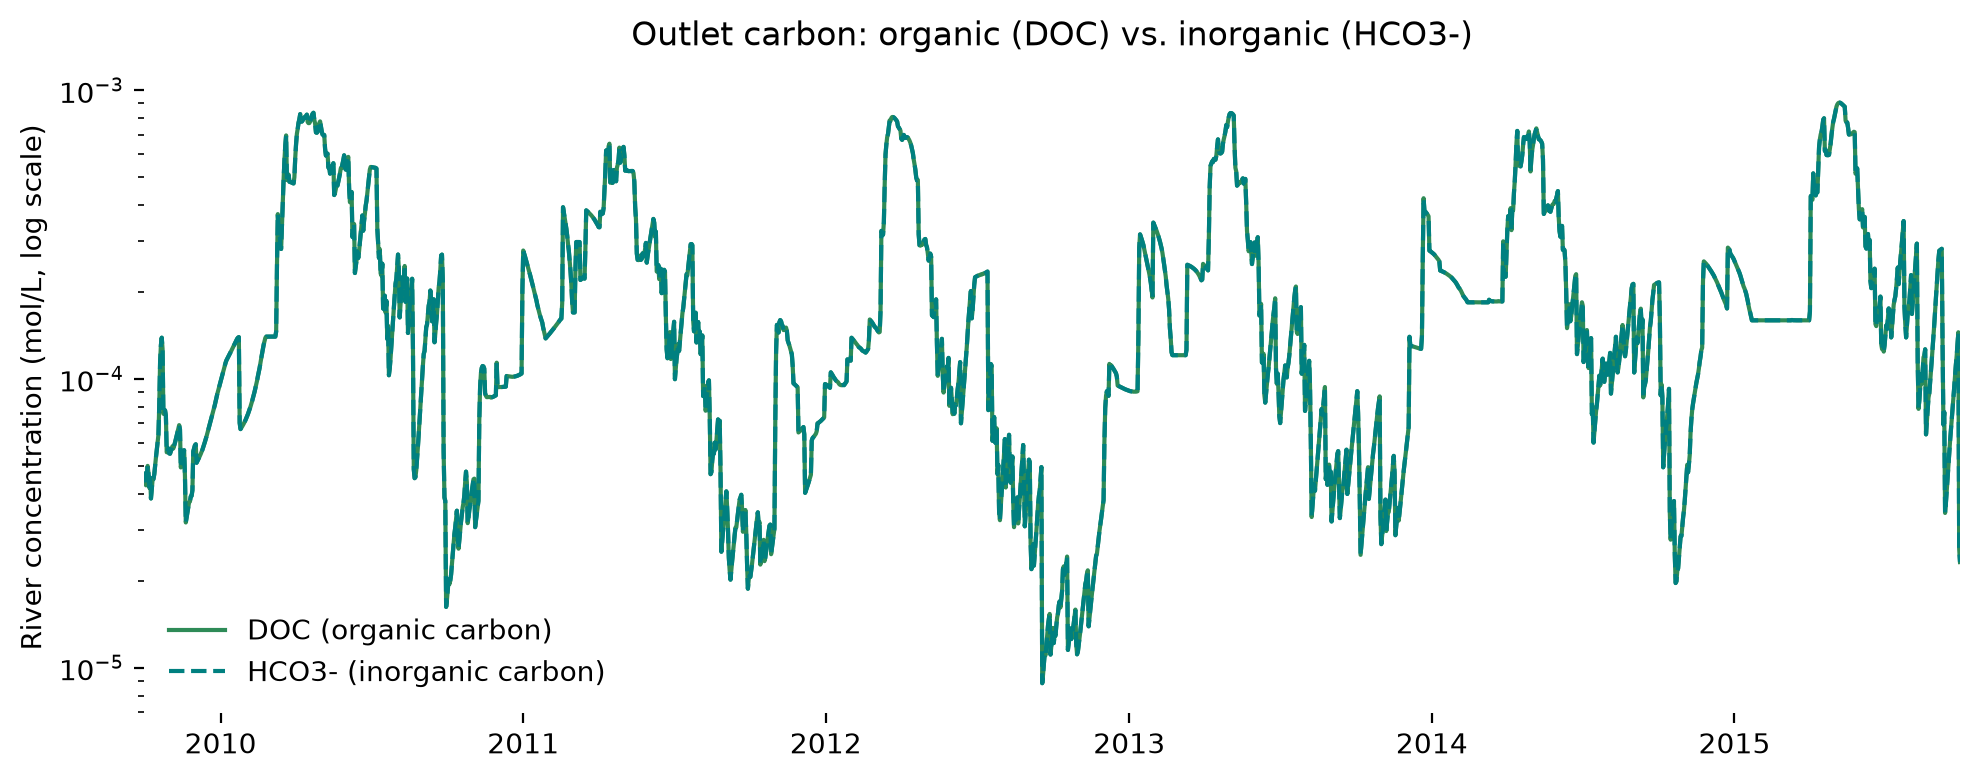

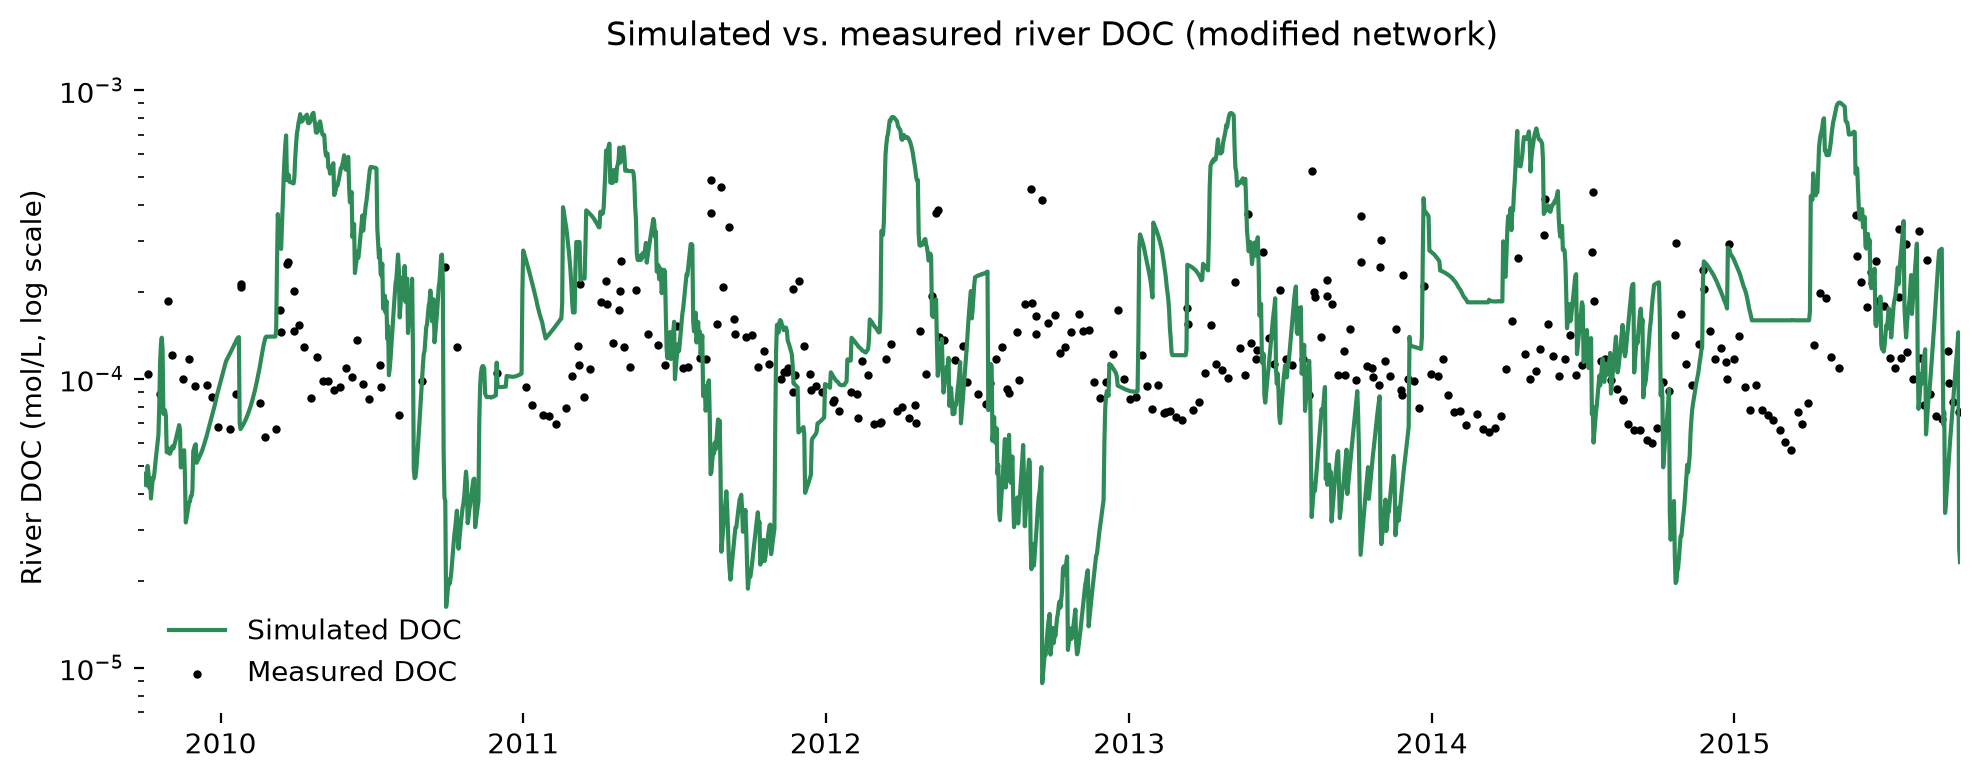

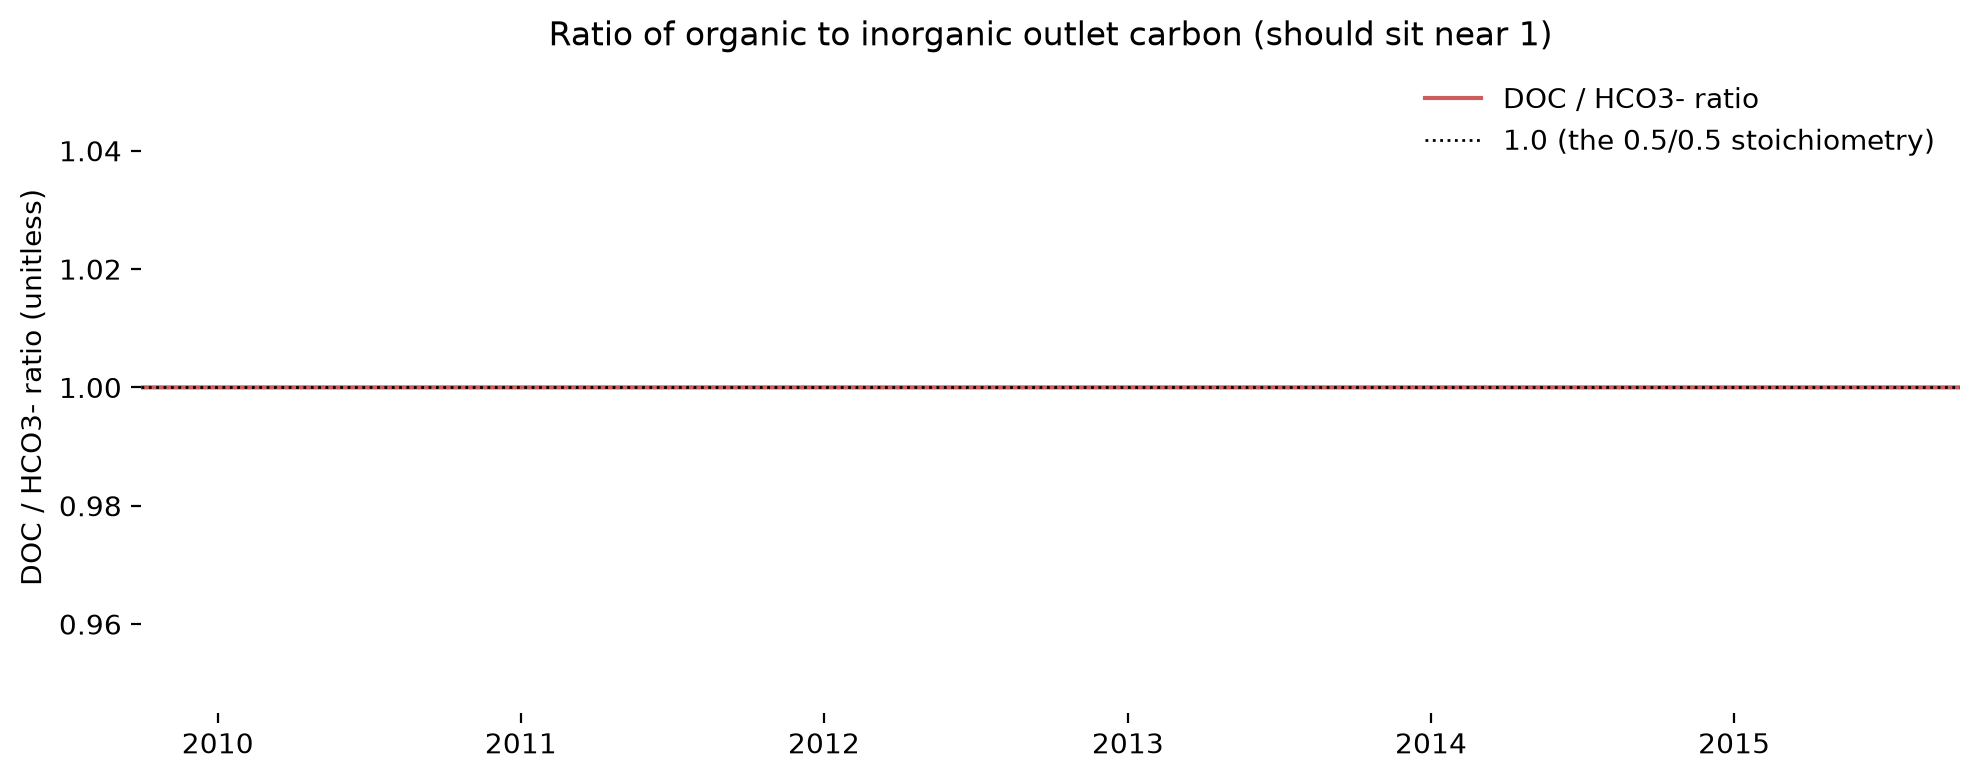

In [ ]:
plt.rcParams["figure.dpi"] = 200
plt.rcParams["legend.frameon"] = False
plt.rcParams["axes.spines.bottom"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.left"] = False
plt.rcParams["axes.spines.right"] = False

obs_start: pd.Timestamp = meas_streamflow.index[0]
obs_end: pd.Timestamp = meas_streamflow.index[-1]
doc_obs: Series = meas_river_conc["DOC"]

# ---- Panel 1: both carbon products in the river ---- #
fig: Figure = plt.figure(figsize=(10, 4))
ax: Axes = fig.gca()

ax.plot(rt_df.index, rt_df["DOC_riv"], color="seagreen", label="DOC (organic carbon)")
ax.plot(
    rt_df.index,
    rt_df["HCO3-_riv"],
    color="teal",
    linestyle="--",
    label="HCO3- (inorganic carbon)",
)
ax.set_yscale("log")
ax.set_xlim(obs_start, obs_end)
ax.set_ylabel("River concentration (mol/L, log scale)")
ax.set_title("Outlet carbon: organic (DOC) vs. inorganic (HCO3-)")
ax.legend()
fig.tight_layout()
plt.show()

# ---- Panel 2: simulated vs. measured DOC ---- #
fig2: Figure = plt.figure(figsize=(10, 4))
ax2: Axes = fig2.gca()

ax2.plot(rt_df.index, rt_df["DOC_riv"], color="seagreen", label="Simulated DOC")
ax2.scatter(doc_obs.index, doc_obs, s=4, color="black", label="Measured DOC")
ax2.set_yscale("log")
ax2.set_xlim(obs_start, obs_end)
ax2.set_ylabel("River DOC (mol/L, log scale)")
ax2.set_title("Simulated vs. measured river DOC (modified network)")
ax2.legend()
fig2.tight_layout()
plt.show()